In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import BatchNormalization
from keras.preprocessing.image import ImageDataGenerator

es = EarlyStopping(monitor = "val_loss", mode = "min", patience = 5)

EPOCHS = 100


In [2]:
root_path = "flowers/"
classes = os.listdir(root_path)

In [3]:
gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    validation_split=0.2
)

# Load Data
train_ds = gen.flow_from_directory(
    root_path,
    class_mode="categorical",
    classes = os.listdir(root_path),
    shuffle=True,
    batch_size=32,
    target_size=(128,128),
    subset="training"
)

valid_ds = gen.flow_from_directory(
    root_path,
    class_mode="categorical",
    classes = os.listdir(root_path),
    shuffle=True,
    batch_size=32,
    target_size=(128,128),
    subset="validation"
)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint

save_best = ModelCheckpoint('./best_model.h5', monitor='val_loss', save_best_only=True)

In [5]:
model = Sequential()
model.add(Conv2D(filters =16, kernel_size = (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(BatchNormalization())
model.add(Conv2D(filters = 32, kernel_size = (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(BatchNormalization())
model.add(Conv2D(filters = 32, kernel_size = (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(5, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 16)       0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 63, 63, 16)       64        
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 32)       0         
 2D)                                                             
                                                        

2023-01-03 12:20:53.401650: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-03 12:20:53.453835: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-03 12:20:53.454149: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-03 12:20:53.454896: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

In [6]:
model.compile(optimizer="adam", loss='categorical_crossentropy',metrics=['accuracy'])
history = model.fit(train_ds, epochs=EPOCHS, validation_data=(valid_ds), callbacks = [es, save_best])

Epoch 1/100


2023-01-03 12:20:55.172770: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8700


109/109 [==============================] - 17s 140ms/step - loss: 1.4875 - accuracy: 0.4212 - val_loss: 1.5735 - val_accuracy: 0.3023
Epoch 2/100
109/109 [==============================] - 15s 133ms/step - loss: 1.1023 - accuracy: 0.5401 - val_loss: 1.5951 - val_accuracy: 0.3360
Epoch 3/100
109/109 [==============================] - 15s 134ms/step - loss: 0.9852 - accuracy: 0.6066 - val_loss: 2.0875 - val_accuracy: 0.2709
Epoch 4/100
109/109 [==============================] - 14s 133ms/step - loss: 1.0216 - accuracy: 0.5875 - val_loss: 1.1592 - val_accuracy: 0.5279
Epoch 5/100
109/109 [==============================] - 15s 134ms/step - loss: 0.9189 - accuracy: 0.6373 - val_loss: 1.0273 - val_accuracy: 0.5977
Epoch 6/100
109/109 [==============================] - 15s 138ms/step - loss: 0.8828 - accuracy: 0.6471 - val_loss: 0.9529 - val_accuracy: 0.6070
Epoch 7/100
109/109 [==============================] - 15s 133ms/step - loss: 0.8380 - accuracy: 0.6743 - val_loss: 1.1196 - val_accurac

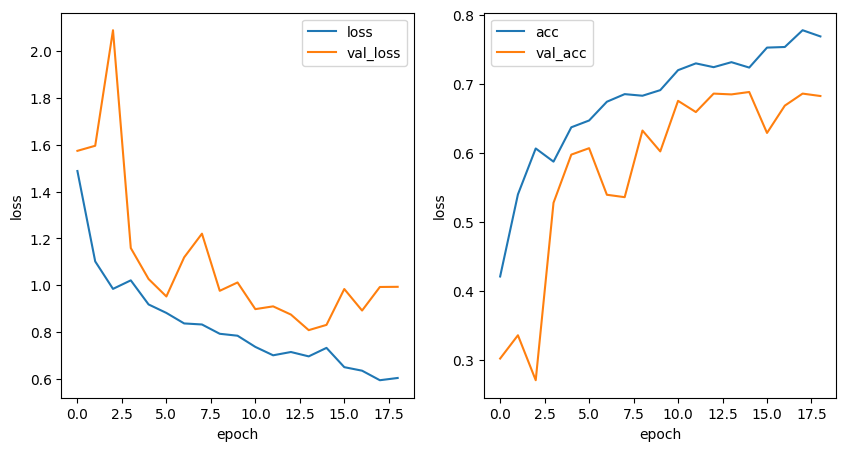

In [9]:
hist = pd.DataFrame(history.history)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hist.loss, label = "loss")
plt.plot(hist.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.accuracy, label = "acc")
plt.plot(hist.val_accuracy, label = "val_acc")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()